In [1]:
import numpy as np
import matplotlib.pyplot as plt

class FixedVarianceAsymmetricDetector2D:
    def __init__(self, step_threshold_z=3.5, exp_collapse_floor=0.15, warmup_period=20):
        """
        step_threshold_z: Z-score multiplier for the mean shift in Signal A.
        exp_collapse_floor: The near-zero bound for Signal B.
        warmup_period: Iterations used to lock down the baseline standard deviation.
        """
        self.threshold_z = step_threshold_z
        self.exp_floor = exp_collapse_floor
        self.warmup = warmup_period
        
        self.count = 0
        self.step_mean = 0.0
        self.step_M2 = 0.0
        self.step_std = None  # Will be locked after warmup

    def process_point(self, val_step, val_exp):
        """Processes exactly ONE incoming real-time point."""
        self.count += 1

        # 1. Warmup Phase: Learn the stable standard deviation of Signal A
        if self.count <= self.warmup:
            delta = val_step - self.step_mean
            self.step_mean += delta / self.count
            self.step_M2 += delta * (val_step - self.step_mean)
            
            if self.count == self.warmup:
                # Lock the variance and standard deviation here
                variance = self.step_M2 / (self.warmup - 1)
                self.step_std = max(variance ** 0.5, 1e-6)
            return "WARMUP"

        # 2. Evaluate Signal A using the locked historical standard deviation
        # This keeps the math stable even if the mean shifts aggressively
        step_z_score = (val_step - self.step_mean) / self.step_std

        # 3. Evaluate Signal B (Exponential collapse tracking)
        is_exp_collapsing = 0 <= val_exp <= self.exp_floor

        # 4. Instant Dual-Trigger Condition
        if step_z_score > self.threshold_z and is_exp_collapsing:
            return "EVENT_DETECTED"
        
        # Update the mean baseline for Signal A only if it's a normal point
        # to prevent baseline pollution
        delta = val_step - self.step_mean
        self.step_mean += delta / (self.count - self.warmup + 1)
        return "NORMAL"

# --- Live Streaming Simulation Loop ---
np.random.seed(42)
total_points = 80
event_step = 45
stable_std = 1.2  # Standard deviation remains identical in both states

# Signal A: Mean shifts from 10 to 22, Standard Deviation stays at 1.2
sig_step = np.concatenate([
    np.random.normal(10.0, stable_std, event_step), 
    np.random.normal(22.0, stable_std, total_points - event_step)
])

# Signal B: Exponential background distribution collapsing to near-zero
sig_exp = np.concatenate([
    np.random.exponential(scale=4.5, size=event_step), 
    np.random.exponential(scale=0.01, size=total_points - event_step)
])

detector = FixedVarianceAsymmetricDetector2D(step_threshold_z=3.5, exp_collapse_floor=0.15, warmup_period=20)
detected_idx = None

for t in range(total_points):
    status = detector.process_point(sig_step[t], sig_exp[t])
    if status == "EVENT_DETECTED":
        detected_idx = t
        print(f"💥 [Step {t}] INSTANT EVENT DETECTED!")
        print(f"   -> Locked Noise Baseline (Std Dev): {detector.step_std:.2f}")
        print(f"   -> Signal A Mean Jumped to: {sig_step[t]:.2f}")
        print(f"   -> Signal B Collapsed to: {sig_exp[t]:.4f}")
        break

💥 [Step 45] INSTANT EVENT DETECTED!
   -> Locked Noise Baseline (Std Dev): 1.15
   -> Signal A Mean Jumped to: 21.14
   -> Signal B Collapsed to: 0.0033


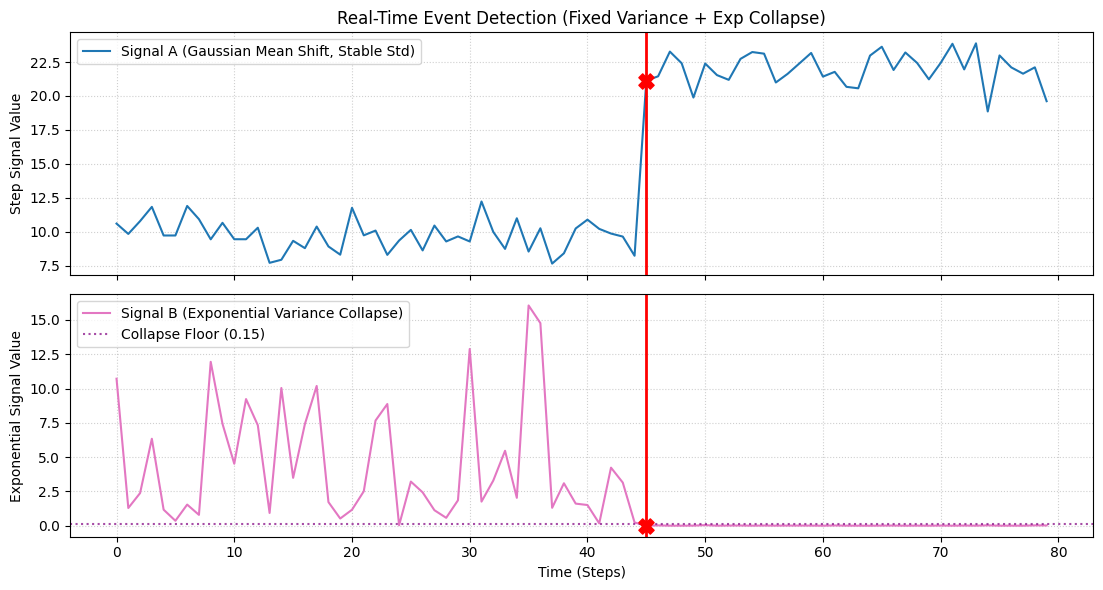

In [2]:
# --- Generate the Visualization ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

# Signal A Subplot
ax1.plot(sig_step, color="#1f77b4", linewidth=1.5, label="Signal A (Gaussian Mean Shift, Stable Std)")
ax1.set_title("Real-Time Event Detection (Fixed Variance + Exp Collapse)")
ax1.set_ylabel("Step Signal Value")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left")

# Signal B Subplot
ax2.plot(sig_exp, color="#e377c2", linewidth=1.5, label="Signal B (Exponential Variance Collapse)")
ax2.axhline(y=0.15, color="purple", linestyle=":", alpha=0.7, label="Collapse Floor (0.15)")
ax2.set_ylabel("Exponential Signal Value")
ax2.set_xlabel("Time (Steps)")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper left")

if detected_idx is not None:
    # Anchor the exact step point across both charts
    ax1.axvline(x=detected_idx, color="red", linestyle="-", linewidth=2)
    ax1.scatter(detected_idx, sig_step[detected_idx], color="red", marker="X", s=120, zorder=5)
    
    ax2.axvline(x=detected_idx, color="red", linestyle="-", linewidth=2)
    ax2.scatter(detected_idx, sig_exp[detected_idx], color="red", marker="X", s=120, zorder=5)

plt.tight_layout()
plt.show()